# Reasoning Path Length — Comparing Reasoning Paths with Equal Correctness

**Motivation.** For the same question and the same compute level, sampled reasoning paths that are *all is_correct* can differ several-fold in length. Correctness is therefore not what separates them. The question is what the extra tokens *do*.

> **Research question.** When a model uses more reasoning tokens, do the additional tokens provide useful information/verification, or do they mainly reflect overthinking, repetition, hesitation, or backtracking?

**Setup.**
* Unit of analysis: `question_id × compute_level` (≈5 sampled paths each). All comparisons are made *within* a group, so question difficulty and compute level are held fixed.
* Equal-correctness analysis: is_correct, non-empty, non-truncated paths from groups where *all* paths are is_correct.
* Consistently-incorrect groups (all paths wrong) are analysed separately (§6b) and never mixed with the above.
* Every text-derived quantity is a **proxy**. Nothing here observes the model's internal computation, and no counterfactual (truncate-and-regenerate) evaluation is run.

**Input:** `h1_raw_results.csv` with columns `question_id`, `compute_level`, `thinking_text`, `thinking_tokens`, `is_correct`; optional: `gold`, `final_answer`, `truncated`.

**Notebook map:** 1 setup · 2 data · 3 method (segmentation → answer tracking → SBERT similarity → labels → per-path metrics) · 4 combined score · 5 sanity checks · 6 within-group statistics, extra-token attribution, figures · 6b consistently-incorrect groups · 7 save outputs + bottom line.

### Metrics

| Metric | Family | Definition (proxy) | Direction | Enters score as |
|---|---|---|---|---|
| `thinking_tokens` | length | Reported reasoning length (tokens). Never enters the score directly; segment token counts = this value distributed by character share. | context | – |
| `first_answer_pos` | timing | Fraction of tokens consumed when the final is_correct answer is first asserted (explicit answer statement, or a computation result equal to the answer). | context | – |
| `post_answer_frac` | timing | 1 − `first_answer_pos`: share of the trace written after the answer was first established. | context (high = long tail) | via `c_necess` |
| `answer_flips` | backtracking | Number of times the *asserted* answer changes (assertions only; hedged / negated / "maybe" mentions of alternatives are excluded). | lower better | `c_stab` (per 1k tokens) |
| `n_doubt` | backtracking | Number of segments with hesitation / self-correction cues (wait, hmm, actually, not sure, that's wrong, …). | lower better | `c_conf` (per 1k tokens) |
| `redundancy` | repetition | Token share of segments whose max similarity to any earlier segment ≥ threshold (semantic repeat); verification segments are exempt. | lower better | `c_nonred` |
| `unique_4gram_ratio` | repetition | Mean fraction of unique word 4-grams in 128-word windows (length-robust lexical repetition). | higher better | `c_div` |
| `n_restate` | repetition | Number of non-final segments that re-assert the answer already held (repeated conclusions). | lower better (diagnostic) | – |
| `information_gain` | usefulness | Token-weighted novelty (semantic + content-word) of the *second half* of the trace, with doubt / wrong-candidate segments counted as zero. | higher better | `c_info` |
| `post_answer_verification` | usefulness | Share of post-answer tokens in segments with verification cues that are not near-duplicates of earlier text. NaN if (almost) nothing follows the answer. | higher better | `c_verif` |
| `critical_prefix_ratio` | necessity | Lower bound: tokens up to the first point where the is_correct answer is asserted and never contradicted afterwards / total tokens. | context | – |
| `useful_prefix_ratio` | necessity | Upper bound: as above but extended to the last post-answer segment that is verification or brings new quantitative content. | higher better | `c_necess` |

## 1. Setup

In [1]:
import math, os, re, warnings
from collections import Counter
import numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sentence_transformers import SentenceTransformer
from IPython.display import HTML, Markdown, display

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

In [2]:
CFG = dict(
    results_dir="results_reasoning_paths",
    seed=0,

    embedder="sbert:all-MiniLM-L6-v2",
    sim_repeat={"sbert": 0.85},
    sim_dup_verif=0.90,
    sim_revisit=0.50,

    w_sem_novelty=0.5,
    tau_new=0.35,
    tau_new_high=0.60,
    min_post_tokens=30,
    ngram_window=128,

    n_boot=1000,
    n_viz_groups=4,
    viz_x_mode="tokens",

    score=dict(
        weights=dict(
            c_info=0.25,
            c_nonred=0.20,
            c_div=0.10,
            c_stab=0.10,
            c_conf=0.10,
            c_verif=0.10,
            c_necess=0.15,
        ),
        agg="arith",
        geo_eps=0.02,
        rate_floor_tokens=1000,
        caps=dict(
            info=0.60,
            red=0.60,
            div_lo=0.50,
            div_hi=0.95,
            flips_per_1k=3.0,
            doubt_per_1k=10.0,
        ),
        verif_missing=0.5,
    ),

    sanity=dict(
        min_rank_corr_weights_p05=0.85,
        min_rank_corr_loo=0.75,
        max_single_component_rank_corr=0.90,
        max_abs_length_rho=0.50,
        max_length_r2=0.50,
    ),
)

# Fixed analysis constants
GK = ["question_id", "compute_level"]      # unit of analysis
MIN_GROUP_N = 3                            # minimum usable paths per group
MIN_LEN_RATIO = 1.5                        # max/min token ratio for a "substantial length spread"
SEG_MIN_CHARS, SEG_MAX_SEGMENTS = 15, 2000 # sentence fragments shorter than this are merged forward; longer traces are coarsened
SIM_REPEAT = CFG["sim_repeat"]["sbert"]    # cosine >= threshold => segment repeats earlier content

np.random.seed(CFG["seed"])
RES_DIR = CFG["results_dir"]; os.makedirs(f"{RES_DIR}/figures", exist_ok=True)

## 2. Data

Paths are grouped by `question × compute`. The **equal-correctness frame** keeps is_correct, non-empty, non-truncated paths from groups in which every path is is_correct; the **consistently-incorrect frame** (all paths wrong) is kept separate.

In [4]:
RAW = pd.read_csv("unneccessary_pathes.csv")

df = RAW.dropna(subset=["is_correct"]).copy()
df["question_id"] = df["question_id"].astype(str); df["compute_level"] = df["compute_level"].astype(str)
df["thinking_text"] = df["thinking_text"].fillna("").astype(str)
df["is_correct"] = df["is_correct"].astype(bool)
tok = pd.to_numeric(df["thinking_tokens"], errors="coerce")
df["thinking_tokens"] = tok.where(tok > 0, df["thinking_text"].str.len() / 4.0)   # chars/4 where the count is missing
df["row_id"] = np.arange(len(df))
df["is_empty"] = df["thinking_text"].str.strip().eq("")
truncated = df["truncated"].fillna(False).astype(bool) if "truncated" in df else pd.Series(False, index=df.index)
df["eligible_correct"] = df["is_correct"] & ~df["is_empty"] & ~truncated

gs = df.groupby(GK).agg(n=("row_id", "size"), n_correct=("is_correct", "sum")).reset_index()

def keep_min_n(d): return d[d.groupby(GK)["row_id"].transform("size") >= MIN_GROUP_N].copy()

df_eq = df.merge(gs.loc[gs.n == gs.n_correct, GK], on=GK);  df_eq = keep_min_n(df_eq[df_eq.eligible_correct])    # equal-correctness

print(f"rows: {len(df)} | empty thinking: {int(df.is_empty.sum())} | groups: {len(gs)} (sizes {gs.n.value_counts().sort_index().to_dict()}) | "
      f"all-is_correct: {int((gs.n == gs.n_correct).sum())} | all-incorrect: {int((gs.n_correct == 0).sum())}")
print(f"Equal-correctness analysis: {df_eq.groupby(GK).ngroups} groups / {len(df_eq)} paths")


rows: 100 | empty thinking: 0 | groups: 20 (sizes {5: 20}) | all-is_correct: 20 | all-incorrect: 0
Equal-correctness analysis: 20 groups / 100 paths


## 3. Method: how a reasoning trace is turned into measurements

All metrics come from one pipeline, applied per `question × compute` group:

1. **Segmentation.** The trace is split into sentence-like *segments* (newlines, then sentence punctuation that is not a decimal point; fragments shorter than 15 characters are merged forward). Segment token counts = `thinking_tokens` × character share, so segment lengths always sum to the reported `thinking_tokens`.
2. **Answer assertions (not mentions).** A segment *asserts* an answer if it either (a) contains answer language ("the answer is X", `\boxed{X}`, "final answer …") **and** is not hedged (`maybe`, `might`, `?`, `suppose`, …) and the value is not negated, or (b) states a computation result (`= X`, `gives X`) whose value is a candidate answer of the same trace. Hedged or negated mentions of other values are **not** assertions, so `answer_flips` counts genuine changes of position rather than alternatives being discussed.
3. **Reference answer.** Gold answer if the data has one; else the consensus final answer of the (all-is_correct) group; else each path's own final answer. Paths in consistently-incorrect groups use their own final answer as reference.
4. **Similarity.** Segments are embedded with SBERT (`all-MiniLM-L6-v2`); `max_sim_prev` = max cosine similarity to any earlier segment of the same path.
5. **Segment labels** (mutually exclusive, priority order): `first_answer` › `wrong_candidate` (asserts a value ≠ reference) › `verification` (post-answer, verification cue, not a near-duplicate) › `doubt` (hesitation / self-correction cue) › `restate` (re-asserts the held answer) › `repetition` (`max_sim_prev ≥ τ`) › `new_reasoning` (post-answer) / `before_answer`.

**Limitations that matter for interpretation.** Cue lexicons are English and heuristic; answer detection is most reliable for short numeric / option answers; token attribution by character share is approximate. Use the labelled-path viewer in §3.3 to audit the heuristics on your own data before trusting any aggregate.

### 3.1 Text utilities, lexicons, segmentation, answer extraction

In [5]:
STOP = set("a an the of to and or in on for is are was were be been it this that these those we i you they with as by at from so then now let us lets can will would should could if but not no yes do does did have has had which what there here my our their its than into out up down over under again also just very more most such only own same too".split())

NUM_RE   = re.compile(r"(?<![\w.])(-?\d[\d,]*(?:\.\d+)?(?:/\d+)?)(?!\w)")
BOXED_RE = re.compile(r"\\boxed\{([^{}]*)\}")
# option letters are matched case-sensitively (only the keywords are case-insensitive) so "the answer is a number" is not read as option A
OPT_RE   = re.compile(r"\(([A-E])\)|\b(?i:option|choice)\s+\(?([A-E])\)?(?=[\s.,;:)]|$)|\b(?i:answer\s*(?:is|:)?)\s*\(?([A-E])\)?(?=[\s.,;:)]|$)")
ANS_RE   = re.compile(r"\b(?:final\s+)?answer\s*(?:is|=|:|would be|should be|must be|will be|comes out to)|\\boxed|\bfinal answer\b|\bi(?:'ll| will) go with\b|\bwe conclude\b|\bconclude that\b|\bthe result is\b")
HEDGE_RE = re.compile(r"\b(?:maybe|perhaps|possibly|might|could be|could it|what if|suppose|let'?s say|alternatively|or is it|should it be|not sure|unsure|i guess|probably)\b|\?")
DOUBT_RE = re.compile(r"\b(?:wait|hmm+|hold on|hold up|actually|maybe|perhaps|not sure|unsure|uncertain|reconsider|rethink|second[- ]guess|on second thought|is that right|does that make sense|something(?:'s| is) off|i(?:'m| am) not (?:sure|certain)|that (?:doesn't|does not|can't|cannot) (?:seem|look|sound|be) right)\b")
REJECT_RE= re.compile(r"\b(?:that(?:'s| is) (?:wrong|incorrect|not right|not is_correct)|is (?:wrong|incorrect)|mistake|doesn't work|does not work|contradiction|contradicts|i made an error|let me redo|start over|try again|scratch that|that can't be|not is_correct)\b|\bno,")
VERIFY_RE= re.compile(r"\b(?:verify|verifying|verified|verification|double[- ]?check(?:ing)?|sanity check|cross[- ]?check|plug(?:ging)?(?: it)? (?:back|in)|substitut\w*|confirm\w*|check(?:ing)? (?:that|this|by|whether|if|the)|re-?comput\w*|re-?calculat\w*|another way|consistent with|matches (?:the|our|my)|to be safe|as a check|checks out)\b")
NEG_RE   = re.compile(r"(?:\bnot\b|n't\b|\bnever\b|\bcannot\b|\bno longer\b|\bwrong\b|\bincorrect\b|\bother than\b)")
RESULT_CTX = re.compile(r"(?:=|\bis|\bare|\bequals?|\bgives?|\bget|\bgets|\bgot|\bmakes|\byields?|\bresults? in)\s*[\$\\(]*\s*$")

In [6]:
def norm_val(s):
    s = str(s).strip().strip("$ .,;:*").replace(",", ""); s2 = s.rstrip("%")
    try:
        if re.fullmatch(r"-?\d+/\d+", s2):
            a, b = s2.split("/"); return f"{float(a)/float(b):.6g}"
        return f"{float(s2):.6g}"
    except Exception:
        return re.sub(r"\s+", " ", s.lower())

def is_numeric(v):
    try: float(v); return True
    except Exception: return False

def value_tokens(sent, extra=()):
    """All candidate answer values in a sentence as (position, normalised value, kind)."""
    out = []
    for m in BOXED_RE.finditer(sent): out.append((m.start(1), norm_val(m.group(1)), "boxed"))
    for m in NUM_RE.finditer(sent): out.append((m.start(1), norm_val(m.group(1)), "num"))
    for m in OPT_RE.finditer(sent):
        g_ = next(x for x in m.groups() if x); out.append((m.start(), g_.upper(), "opt"))
    low = sent.lower()
    for e in extra:
        i = low.find(e)
        while i >= 0 and e: out.append((i, e, "txt")); i = low.find(e, i + 1)
    out.sort(key=lambda x: x[0]); return out

def norm_answer(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return None
    s = str(x).strip()
    if not s: return None
    m = BOXED_RE.findall(s)
    if m: return norm_val(m[-1])
    v = value_tokens(s)
    if v and len(s) < 40: return v[-1][1]
    return norm_val(s)

In [7]:
def split_segments(text):
    raw = []
    for line in re.split(r"\n+", text.replace("\r", "")):
        line = line.strip()
        if not line: continue
        raw.extend(p.strip() for p in re.split(r"(?<=[.!?])\s+(?=[A-Z\\$(\"'*\d])", line) if p.strip())
    segs, buf = [], ""
    for p in raw:
        buf = (buf + " " + p).strip() if buf else p
        if len(buf) >= SEG_MIN_CHARS: segs.append(buf); buf = ""
    if buf:
        if segs: segs[-1] += " " + buf
        else: segs.append(buf)
    if len(segs) > SEG_MAX_SEGMENTS:
        k = math.ceil(len(segs) / SEG_MAX_SEGMENTS); segs = [" ".join(segs[i:i + k]) for i in range(0, len(segs), k)]
    return segs

In [8]:
def seg_features(seg, extra=()):
    """Cue flags + answer assertions for one segment."""
    low = seg.lower(); vals = value_tokens(seg, extra)
    hedge = bool(HEDGE_RE.search(low)); ans = ANS_RE.search(low)
    neg = lambda p: bool(NEG_RE.search(low[max(0, p - 25):p]))
    explicit, results = None, []
    if not hedge:
        if ans:
            cand = [v for (p, v, k) in vals if (p >= ans.end() or k == "boxed") and not neg(p)]
            if cand: explicit = cand[0] if not any(k == "boxed" for _, _, k in vals) else [v for _, v, k in vals if k == "boxed"][-1]
        for (p, v, k) in vals:
            if RESULT_CTX.search(low[max(0, p - 22):p]) and not neg(p): results.append(v)
    return dict(vals=[(p, v) for p, v, k in vals], explicit=explicit, results=results, hedge=hedge,
                doubt=bool(DOUBT_RE.search(low)), reject=bool(REJECT_RE.search(low)), verify=bool(VERIFY_RE.search(low)))

def final_from_feats(feats):
    for f in reversed(feats):
        if f["explicit"] is not None: return f["explicit"]
    for f in reversed(feats[-3:]):
        if f["results"]: return f["results"][-1]
        if f["vals"]: return f["vals"][-1][1]
    return None

In [9]:
def unique_4gram_ratio(text, window):
    """Mean fraction of unique word 4-grams in `window`-word windows (whole text if it has < 32 words)."""
    w = re.findall(r"\w+", text.lower())
    def ratio(x):
        g = list(zip(x, x[1:], x[2:], x[3:])); return len(set(g)) / len(g) if g else np.nan
    if len(w) < 32: return ratio(w)
    rs = [ratio(w[i:i + window]) for i in range(0, len(w), window) if len(w[i:i + window]) >= 32]
    return float(np.nanmean(rs)) if rs else ratio(w)

### 3.2 Per-group analysis

`analyze_group` orchestrates one `question × compute` group; each step of the method (items 3–5 above plus the metric computation) is its own small function.

In [10]:
def resolve_reference(g, keys, feats_by, gold, mode):
    """Reference answer per path. mode='group': gold, else group consensus; mode='own' (or no consensus): each path's own final answer."""
    finals = {}
    for k in keys:
        pn = norm_answer(g.at[k, "pred"]) if "pred" in g.columns else None
        finals[k] = pn if pn is not None else final_from_feats(feats_by[k])
    ref_all, ref_src = None, "own_final"
    if mode == "group":
        if gold is not None and norm_answer(gold) is not None: ref_all, ref_src = norm_answer(gold), "gold"
        else:
            c = Counter([v for v in finals.values() if v is not None])
            if c and c.most_common(1)[0][1] / len(keys) >= 0.5: ref_all, ref_src = c.most_common(1)[0][0], "consensus"
    refs = {k: (ref_all if ref_all is not None else finals[k]) for k in keys}
    return refs, finals, (ref_src if ref_all is not None else "own_final")

def refine_text_reference_features(segs_by, feats_by, refs):
    """Non-numeric, non-option references need substring matching, so re-extract features with the reference as an extra value."""
    for k, r in refs.items():
        if r is not None and not is_numeric(r) and len(r) <= 40 and not re.fullmatch(r"[A-E]", str(r)):
            feats_by[k] = [seg_features(s, extra=(r,)) for s in segs_by[k]]

In [11]:
def track_answer(feats, ref):
    """Follow the asserted answer through the trace: flips, restatements, wrong assertions, first/stable is_correct position."""
    n = len(feats)
    cand = {c for c in ({ref} | {f["explicit"] for f in feats}) if c is not None}
    av = []
    for f in feats:
        if f["explicit"] is not None: av.append(f["explicit"])
        else:
            rr = [r for r in f["results"] if r in cand]; av.append(rr[-1] if rr else None)
    cur, flips = None, 0; restate = np.zeros(n, bool)
    for i, v in enumerate(av):
        if v is None: continue
        if cur is None: cur = v
        elif v != cur: flips += 1; cur = v
        else: restate[i] = True
    wrong = np.array([(v is not None and ref is not None and v != ref) for v in av], dtype=bool)
    first = next((i for i, v in enumerate(av) if ref is not None and v == ref), None); method = "assert" if first is not None else "none"
    if first is None and ref is not None:
        first = next((i for i, f in enumerate(feats) if any(v == ref for _, v in f["vals"])), None)
        method = "mention" if first is not None else "none"
    lw = max([i for i in range(n) if wrong[i]], default=-1)
    stable = next((i for i, v in enumerate(av) if ref is not None and v == ref and i > lw), None)
    return dict(av=av, flips=flips, restate=restate, wrong=wrong, first=first, method=method, stable=stable)

In [12]:
SBERT = SentenceTransformer(CFG["embedder"].split(":", 1)[1])
def embed(segs): return SBERT.encode(list(segs), normalize_embeddings=True, show_progress_bar=False)

def similarity_and_novelty(segs):
    """max similarity to any earlier segment, exact duplicates, content-word novelty, and the combined novelty score."""
    n = len(segs)
    X = embed(segs); S = X @ X.T
    L = np.where(np.tril(np.ones((n, n), bool), -1), S, -1.0)
    msp = np.zeros(n)
    if n > 1: msp[1:] = np.clip(L[1:].max(axis=1), 0, 1)
    seen_txt, exact = {}, np.zeros(n, bool)
    for i, s in enumerate(segs):
        key = re.sub(r"[^a-z0-9]", "", s.lower())
        if key in seen_txt: exact[i] = True; msp[i] = 1.0
        seen_txt.setdefault(key, i)
    seen, seen_num = set(), set(); cn = np.zeros(n); newnum = np.zeros(n, bool)
    for i, s in enumerate(segs):
        ty = {w for w in re.findall(r"[a-z]+|\d+(?:\.\d+)?", s.lower()) if w[0].isdigit() or (w not in STOP and len(w) > 1)}
        cn[i] = len(ty - seen) / len(ty) if ty else 0.0
        nums = {w for w in ty if w[0].isdigit()}; newnum[i] = bool(nums - seen_num); seen |= ty; seen_num |= nums
    sem = 1 - msp; sem[0] = 1.0
    w = CFG["w_sem_novelty"]; nov = w * sem + (1 - w) * cn
    return dict(S=S, msp=msp, exact=exact, cn=cn, newnum=newnum, nov=nov)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def label_segments(feats, tr, sim, thr, dup_verif):
    """Mutually exclusive segment labels, in the priority order described in the method notes."""
    first = tr["first"]; labels = []
    for i, f in enumerate(feats):
        post = first is not None and i > first
        if first is not None and i == first: lab = "first_answer"
        elif tr["wrong"][i]: lab = "wrong_candidate"
        elif f["verify"] and post and sim["msp"][i] < dup_verif: lab = "verification"
        elif f["doubt"] or f["reject"]: lab = "doubt"
        elif tr["restate"][i]: lab = "restate"
        elif sim["msp"][i] >= thr: lab = "repetition"
        else: lab = "new_reasoning" if post else "before_answer"
        labels.append(lab)
    return np.array(labels)

def count_revisits(feats, S, thr_revisit):
    """Diagnostic: segments that return to (are similar to) an approach that was rejected at least 3 segments earlier."""
    n = len(feats)
    rej = np.array([any(feats[j]["reject"] for j in range(i + 1, min(n, i + 3))) for i in range(n)]); ridx = np.where(rej)[0]; n_revisit = 0
    for i in range(n):
        if feats[i]["reject"]: continue
        js = ridx[ridx <= i - 3]
        if len(js) and S[i, js].max() >= thr_revisit: n_revisit += 1
    return n_revisit

In [14]:
def path_metrics(k, T, ref, ref_src, final, text, feats, tr, sim, labels, tok):
    """All per-path metrics (see the metrics table) from the segment-level quantities."""
    n = len(feats); cum = np.cumsum(tok); first, stable = tr["first"], tr["stable"]; msp, nov = sim["msp"], sim["nov"]
    redundancy = tok[(msp >= SIM_REPEAT) & (labels != "verification")].sum() / T
    late = (cum - tok / 2) >= 0.5 * T
    useful = nov * (~np.isin(labels, ["doubt", "wrong_candidate"]))
    info_gain = (tok[late] * useful[late]).sum() / tok[late].sum() if late.any() else float((tok * useful).sum() / T)
    post = (np.arange(n) > first) if first is not None else np.zeros(n, bool)
    post_tok = tok[post].sum() if first is not None else np.nan
    first_pos = cum[first] / T if first is not None else np.nan
    post_verif = tok[post & (labels == "verification")].sum() / post_tok if (first is not None and post_tok >= max(CFG["min_post_tokens"], 0.02 * T)) else np.nan
    crit = cum[stable] / T if stable is not None else np.nan; useful_prefix = np.nan
    if stable is not None:
        ui = [i for i in range(stable + 1, n) if labels[i] == "verification"
              or (labels[i] == "new_reasoning" and nov[i] >= CFG["tau_new"] and (sim["newnum"][i] or nov[i] >= CFG["tau_new_high"]))]
        useful_prefix = cum[max(ui)] / T if ui else crit
    return dict(row_id=k, thinking_tokens=T, ref_answer=ref, ref_source=ref_src, final_answer=final, answer_detect=tr["method"],
                first_answer_pos=first_pos, post_answer_frac=(1 - first_pos) if first is not None else np.nan,
                answer_flips=tr["flips"], n_restate=int((tr["restate"] & (np.arange(n) < n - 1)).sum()),
                n_doubt=int(sum(f["doubt"] or f["reject"] for f in feats)), n_revisit=count_revisits(feats, sim["S"], CFG["sim_revisit"]),
                redundancy=redundancy, unique_4gram_ratio=unique_4gram_ratio(text, CFG["ngram_window"]), information_gain=info_gain,
                post_answer_verification=post_verif, critical_prefix_ratio=crit, useful_prefix_ratio=useful_prefix)

def segment_rows(k, segs, tok, labels, sim, tr):
    starts = np.cumsum(tok) - tok
    return [dict(row_id=k, seg_idx=i, text=segs[i], tokens=tok[i], tok_start=starts[i], label=labels[i],
                 novelty=sim["nov"][i], max_sim_prev=sim["msp"][i], assertion=tr["av"][i]) for i in range(len(segs))]

def analyze_group(g, gold=None, mode="group"):
    """g: DataFrame(index=row_id; columns text, tokens[, pred]).
    mode='group': one reference answer for all paths (gold, else consensus). mode='own': each path's own final answer.
    Returns (per-path metrics, per-segment rows)."""
    keys = list(g.index)
    segs_by = {k: split_segments(g.at[k, "text"]) for k in keys}
    feats_by = {k: [seg_features(s) for s in segs_by[k]] for k in keys}
    refs, finals, ref_src = resolve_reference(g, keys, feats_by, gold, mode)
    refine_text_reference_features(segs_by, feats_by, refs)
    rows, seg_rows = [], []
    for k in keys:
        segs, feats = segs_by[k], feats_by[k]
        T = float(g.at[k, "tokens"]); chars = np.array([len(s) for s in segs], float); tok = T * chars / chars.sum()
        tr = track_answer(feats, refs[k]); sim = similarity_and_novelty(segs)
        labels = label_segments(feats, tr, sim, SIM_REPEAT, CFG["sim_dup_verif"])
        rows.append(path_metrics(k, T, refs[k], ref_src, finals[k], g.at[k, "text"], feats, tr, sim, labels, tok))
        seg_rows.extend(segment_rows(k, segs, tok, labels, sim, tr))
    return pd.DataFrame(rows), pd.DataFrame(seg_rows)

def run_groups(frame, mode, label):
    """Run analyze_group on every question x compute group. Returns (per-path metrics, per-segment rows)."""
    out_m, out_s = [], []; groups = list(frame.groupby(GK))
    for gi, ((q, lv), gdf) in enumerate(groups, 1):
        g = pd.DataFrame({"text": gdf["thinking_text"].values, "tokens": gdf["thinking_tokens"].values}, index=gdf["row_id"].values)
        if "final_answer" in gdf: g["pred"] = gdf["final_answer"].values
        m, s = analyze_group(g, gold=gdf["gold"].iloc[0] if "gold" in gdf else None, mode=mode)
        m["question_id"], m["compute_level"] = q, lv; s["question_id"], s["compute_level"] = q, lv
        out_m.append(m); out_s.append(s)
        if gi % 50 == 0: print(f"  {label}: {gi}/{len(groups)} groups")
    return pd.concat(out_m, ignore_index=True), pd.concat(out_s, ignore_index=True)

### 3.2b Run the equal-correctness pipeline

In [15]:
df_samples, seg_df = run_groups(df_eq, mode="group", label="equal-correctness")
print(f"{len(df_samples)} paths, {len(seg_df)} segments")
print("answer detection:", df_samples["answer_detect"].value_counts().to_dict(), "| reference source:", df_samples["ref_source"].value_counts().to_dict())
print(f"share of paths where the group reference answer equals the path's own extracted final answer: {(df_samples.ref_answer == df_samples.final_answer).mean():.2%}")

100 paths, 4658 segments
answer detection: {'assert': 92, 'none': 5, 'mention': 3} | reference source: {'gold': 100}
share of paths where the group reference answer equals the path's own extracted final answer: 48.00%


In [17]:
df_samples

,row_id,thinking_tokens,ref_answer,ref_source,final_answer,answer_detect,first_answer_pos,post_answer_frac,answer_flips,n_restate,n_doubt,n_revisit,redundancy,unique_4gram_ratio,information_gain,post_answer_verification,critical_prefix_ratio,useful_prefix_ratio,question_id,compute_level
0,0,412.000,3,gold,3,assert,0.391,0.609,0,2,0,0,0.120,0.993,0.441,0.116,0.391,1.000,GSM8K_1,4096
1,1,410.000,3,gold,3,assert,0.485,0.515,0,1,0,0,0.105,0.991,0.394,0.000,0.485,0.980,GSM8K_1,4096
2,2,375.000,3,gold,3,assert,0.494,0.506,0,1,0,0,0.020,0.996,0.353,0.048,0.494,0.874,GSM8K_1,4096
3,3,694.000,3,gold,3,assert,0.506,0.494,0,0,0,0,0.082,0.971,0.323,0.026,0.506,0.884,GSM8K_1,4096
4,4,"2,415.000",3,gold,3,assert,0.104,0.896,5,9,22,53,0.140,0.973,0.253,0.022,0.970,0.970,GSM8K_1,4096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,268.000,d,gold,None,assert,0.815,0.185,0,0,0,0,0.000,0.984,0.545,0.000,0.815,0.980,MMLU-Redux_6,4096
96,96,391.000,d,gold,D,assert,1.000,0.000,0,0,1,0,0.030,0.996,0.516,NaN,1.000,1.000,MMLU-Redux_6,4096
97,97,759.000,d,gold,None,assert,0.782,0.218,0,0,3,0,0.000,0.994,0.382,0.178,0.782,1.000,MMLU-Redux_6,4096
98,98,"1,026.000",d,gold,None,mention,0.036,0.964,0,0,4,12,0.010,0.998,0.392,0.028,NaN,NaN,MMLU-Redux_6,4096


### 3.3 Audit the heuristics: one labelled path

Colour = segment label. Read a few paths to check that *first answer*, *wrong candidate*, *doubt* and *verification* are assigned sensibly for your model's writing style. If not, adjust the lexicons in §3.1 before interpreting the aggregate statistics.

In [18]:
LABEL_STYLE = {"before_answer": ("#C9CED6", "Before answer"), "first_answer": ("#F2B701", "First answer"), "new_reasoning": ("#3B82C4", "New reasoning (after answer)"),
               "repetition": ("#F28E2B", "Repetition"), "restate": ("#76B7B2", "Restated conclusion"), "wrong_candidate": ("#D62728", "Wrong candidate"),
               "doubt": ("#9467BD", "Doubt / backtrack"), "verification": ("#2CA02C", "Verification")}

def show_labeled_path(row_id, max_segs=60):
    import html
    s = seg_df[seg_df.row_id == row_id].sort_values("seg_idx").head(max_segs)
    parts = [f"<span style='background:{LABEL_STYLE[r.label][0]}33;border-left:4px solid {LABEL_STYLE[r.label][0]};padding:1px 4px;margin:1px;display:block' "
             f"title='{r.label}'><b style='color:{LABEL_STYLE[r.label][0]}'>[{r.label}|nov {r.novelty:.2f}]</b> {html.escape(r.text)}</span>" for r in s.itertuples()]
    display(HTML("<div style='font-family:monospace;font-size:12px;max-width:1000px'>" + "".join(parts) + "</div>"))

In [19]:
_ex = df_samples.sort_values("thinking_tokens").iloc[-1]
print(f"Longest path: question={_ex.question_id} level={_ex.compute_level} tokens={_ex.thinking_tokens:.0f}")
show_labeled_path(_ex.row_id)

Longest path: question=MMLU-Pro_9 level=8192 tokens=5076


## 4. Combined reasoning efficiency / usefulness score

**Goal.** Separate *long-but-useful* from *long-and-redundant* from *short-but-low-quality* reasoning — **without** rewarding brevity and **without** using correctness.

**Design.**
* Seven **components**, each mapped to **[0, 1] with 1 = better**, using fixed *anchored* caps (`CFG["score"]["caps"]`), not per-dataset min-max. Anchored scaling keeps scores comparable across groups and keeps the score in range by construction.
* Counts are converted to **per-1k-token rates** (tokens floored at `rate_floor_tokens`), so a long trace is not penalised merely for having more opportunities to hesitate. Length itself is *not* an input.

| Component | From | Sign | Rationale |
|---|---|---|---|
| `c_info` | `information_gain` | + | Does the late trace still add new, non-hesitation content? |
| `c_nonred` | `1 − redundancy` | + | Semantic repetition of earlier content is wasted tokens. |
| `c_div` | `unique_4gram_ratio` | + | Verbatim / looping repetition (length-robust windowed version). |
| `c_stab` | `answer_flips` per 1k tokens | + (fewer flips) | Genuine answer switching signals instability. |
| `c_conf` | `n_doubt` per 1k tokens | + (less doubt) | Excess hesitation cues. |
| `c_verif` | `post_answer_verification` | + | Post-answer tokens spent on non-duplicate checking. Neutral value (0.5) if nothing follows the answer, so finishing promptly is neither rewarded nor punished. |
| `c_necess` | `useful_prefix_ratio` | + | Share of the trace needed to reach/retain the answer *or* that is verification / new quantitative content. |

**Aggregation.** Weighted arithmetic mean (`agg="arith"`, default) or weighted geometric mean (`"geo"`, punishes any single collapsed component). Components undefined for a path are dropped and the remaining weights renormalised. The weights are a **prior**, not fitted: §5 quantifies how much conclusions depend on them.

In [20]:
SCORE = CFG["score"]

def score_components(m):
    cap = SCORE["caps"]; T = m["thinking_tokens"].clip(lower=SCORE["rate_floor_tokens"])
    c = pd.DataFrame(index=m.index)
    c["c_info"]   = (m["information_gain"] / cap["info"]).clip(0, 1)
    c["c_nonred"] = 1 - (m["redundancy"] / cap["red"]).clip(0, 1)
    c["c_div"]    = ((m["unique_4gram_ratio"] - cap["div_lo"]) / (cap["div_hi"] - cap["div_lo"])).clip(0, 1)
    c["c_stab"]   = 1 - ((m["answer_flips"] / T * 1000) / cap["flips_per_1k"]).clip(0, 1)
    c["c_conf"]   = 1 - ((m["n_doubt"] / T * 1000) / cap["doubt_per_1k"]).clip(0, 1)
    c["c_verif"]  = m["post_answer_verification"].fillna(SCORE["verif_missing"]).clip(0, 1)
    c["c_necess"] = m["useful_prefix_ratio"].clip(0, 1)
    return c

def combine_components(c, weights=None, agg=None):
    weights = weights or SCORE["weights"]; agg = agg or SCORE["agg"]
    w = pd.Series(weights).reindex(c.columns).fillna(0.0)
    W = c.notna().mul(w, axis=1); Wn = W.div(W.sum(axis=1).replace(0, np.nan), axis=0)
    if agg == "arith": s = (c.fillna(0) * Wn).sum(axis=1, min_count=1)
    else: s = np.exp((np.log(c.clip(lower=SCORE["geo_eps"])).fillna(0) * Wn).sum(axis=1, min_count=1))
    return s.where(W.sum(axis=1) > 0)

def add_scores(m):
    c = score_components(m); return pd.concat([m, c], axis=1).assign(score=combine_components(c))

df_samples = add_scores(df_samples)
print("score range:", round(df_samples.score.min(), 3), "-", round(df_samples.score.max(), 3), "| NaN scores:", int(df_samples.score.isna().sum()))
display(df_samples[["c_info", "c_nonred", "c_div", "c_stab", "c_conf", "c_verif", "c_necess", "score"]].describe().T)

score range: 0.362 - 0.95 | NaN scores: 0


,count,mean,std,min,25%,50%,75%,max
c_info,100.000,0.603,0.171,0.218,0.492,0.582,0.682,1.000
c_nonred,100.000,0.865,0.172,0.171,0.794,0.922,1.000,1.000
c_div,100.000,0.998,0.012,0.892,1.000,1.000,1.000,1.000
c_stab,100.000,0.973,0.141,0.000,1.000,1.000,1.000,1.000
c_conf,100.000,0.743,0.305,0.000,0.600,0.900,1.000,1.000
c_verif,100.000,0.180,0.202,0.000,0.027,0.068,0.500,0.542
c_necess,91.000,0.914,0.103,0.607,0.872,0.949,1.000,1.000
score,100.000,0.749,0.112,0.362,0.689,0.757,0.815,0.950


### 4.1 Per-group summary

In [21]:
MEAN_COLS = ["first_answer_pos", "post_answer_frac", "redundancy", "unique_4gram_ratio", "n_restate", "answer_flips", "n_doubt",
             "information_gain", "post_answer_verification", "useful_prefix_ratio", "score"]
gg = df_samples.groupby(GK)
group_df = gg.agg(n_paths=("row_id", "size"), tok_min=("thinking_tokens", "min"), tok_max=("thinking_tokens", "max"),
                  score_range=("score", lambda s: s.max() - s.min())).join(gg[MEAN_COLS].mean().add_suffix("_mean")).reset_index()
group_df["tok_ratio"] = group_df["tok_max"] / group_df["tok_min"].clip(lower=1)
group_df["substantial_length_spread"] = group_df["tok_ratio"] >= MIN_LEN_RATIO
print(f"{len(group_df)} groups | {int(group_df.substantial_length_spread.sum())} with max/min tokens >= {MIN_LEN_RATIO}")
display(group_df.sort_values("tok_ratio", ascending=False).head(8))

20 groups | 20 with max/min tokens >= 1.5


,question_id,compute_level,n_paths,tok_min,tok_max,score_range,first_answer_pos_mean,post_answer_frac_mean,redundancy_mean,unique_4gram_ratio_mean,n_restate_mean,answer_flips_mean,n_doubt_mean,information_gain_mean,post_answer_verification_mean,useful_prefix_ratio_mean,score_mean,tok_ratio,substantial_length_spread
7,IFEval_8,8192,5,58.000,937.000,0.169,NaN,NaN,0.000,1.000,0.000,0.000,0.800,0.500,NaN,NaN,0.882,16.155,True
15,MMLU-Pro_8,8192,5,75.000,879.000,0.140,0.702,0.298,0.009,0.974,0.200,0.000,0.200,0.421,0.022,0.902,0.836,11.720,True
6,GSM8K_9,4096,5,124.000,"1,305.000",0.322,0.640,0.360,0.080,0.973,1.800,0.000,3.400,0.311,0.172,0.887,0.736,10.524,True
14,MMLU-Pro_8,4096,5,98.000,843.000,0.260,0.647,0.353,0.033,0.981,0.400,0.400,0.800,0.434,0.054,0.876,0.790,8.602,True
13,MMLU-Pro_8,2048,5,77.000,555.000,0.175,0.634,0.366,0.025,0.984,0.600,0.000,0.200,0.423,0.048,0.951,0.838,7.208,True
19,MMLU-Redux_6,4096,5,268.000,"1,883.000",0.243,0.555,0.445,0.018,0.994,0.200,0.000,5.200,0.421,0.066,0.987,0.790,7.026,True
12,MMLU-Pro_8,1024,5,98.000,683.000,0.165,0.493,0.507,0.000,0.978,0.200,0.200,0.200,0.424,0.015,0.870,0.812,6.969,True
3,GSM8K_4,8192,5,649.000,"4,257.000",0.247,0.145,0.855,0.335,0.982,10.000,4.400,17.800,0.169,0.024,0.840,0.489,6.559,True


## 5. Score validation / sanity checks

A score that outputs numbers is not automatically meaningful. The checks below are of three kinds:

* **Controlled (synthetic metric vectors)** – range, monotonicity of each component, scenario ordering (*long-useful*, *long-redundant*, *short-efficient*, *short-low-quality*), invariance to pure length scaling.
* **Text-level (synthetic traces through the full pipeline)** – the same trace with redundancy / verification / doubt-and-flips added, checking that the *extracted metrics* and *score* move in the intended direction.
* **Empirical (your data)** – rank stability under random weight perturbations, leave-one-component-out, single-component dominance, and whether the score is just a proxy for shortness.

PASS/FAIL thresholds are in `CFG["sanity"]`. A FAIL is information about the score design or the heuristics, not necessarily a bug.

### 5.1 Controlled checks on synthetic metric vectors

In [23]:
SANITY = []
def record(name, ok, observed, criterion):
    SANITY.append(dict(check=name, status="PASS" if ok else "FAIL", observed=observed, criterion=criterion)); print(f"[{'PASS' if ok else 'FAIL'}] {name}: {observed}")

BASE = dict(thinking_tokens=3000.0, information_gain=0.40, redundancy=0.20, unique_4gram_ratio=0.80, answer_flips=1, n_doubt=6, post_answer_verification=0.30, useful_prefix_ratio=0.60)
def score_of(**kw): return float(combine_components(score_components(pd.DataFrame([{**BASE, **kw}]))).iloc[0])

# (1) range: random plausible + extreme vectors + real paths
rng = np.random.default_rng(CFG["seed"]); N = 5000
R = pd.DataFrame(dict(thinking_tokens=rng.uniform(50, 60000, N), information_gain=rng.uniform(0, 1, N), redundancy=rng.uniform(0, 1, N), unique_4gram_ratio=rng.uniform(0.05, 1, N),
                      answer_flips=rng.integers(0, 40, N), n_doubt=rng.integers(0, 400, N), post_answer_verification=np.where(rng.random(N) < 0.3, np.nan, rng.uniform(0, 1, N)),
                      useful_prefix_ratio=np.where(rng.random(N) < 0.1, np.nan, rng.uniform(0, 1, N))))
for agg in ["arith", "geo"]:
    s = combine_components(score_components(R), agg=agg)
    record(f"range [0,1] ({agg}, {N} random vectors)", bool(s.between(0, 1).all()) and bool(s.notna().all()), f"min={s.min():.3f} max={s.max():.3f}", "all scores in [0,1]")
s_real = df_samples["score"].dropna()
record("range [0,1] (real paths)", bool(s_real.between(0, 1).all()), f"min={s_real.min():.3f} max={s_real.max():.3f}", "all scores in [0,1]")

# (2) monotonicity sweeps
def sweep(metric, vals, direction):
    sc = np.array([score_of(**{metric: v}) for v in vals]); d = np.diff(sc)
    ok = ((d <= 1e-12).all() and d.min() < -1e-9) if direction == "down" else ((d >= -1e-12).all() and d.max() > 1e-9)
    record(f"monotone: {metric} {'up -> score down' if direction == 'down' else 'up -> score up'}", bool(ok), f"{sc[0]:.3f} -> {sc[-1]:.3f}", "non-strictly monotone, not flat")

sweep("redundancy", np.linspace(0, 0.9, 10), "down"); sweep("information_gain", np.linspace(0, 0.9, 10), "up"); sweep("unique_4gram_ratio", np.linspace(0.3, 1, 8), "up")
sweep("post_answer_verification", np.linspace(0, 1, 6), "up"); sweep("useful_prefix_ratio", np.linspace(0.05, 1, 8), "up")
sweep("answer_flips", np.arange(0, 8), "down"); sweep("n_doubt", np.arange(0, 60, 6), "down")

# (3) scenario ordering
SCENARIOS = dict(
    long_useful=dict(thinking_tokens=8000, information_gain=.55, redundancy=.08, unique_4gram_ratio=.88, answer_flips=0, n_doubt=8, post_answer_verification=.6, useful_prefix_ratio=.90),
    long_redundant=dict(thinking_tokens=8000, information_gain=.10, redundancy=.60, unique_4gram_ratio=.55, answer_flips=2, n_doubt=60, post_answer_verification=.03, useful_prefix_ratio=.15),
    short_efficient=dict(thinking_tokens=900, information_gain=.50, redundancy=.05, unique_4gram_ratio=.92, answer_flips=0, n_doubt=1, post_answer_verification=np.nan, useful_prefix_ratio=1.0),
    short_lowquality=dict(thinking_tokens=900, information_gain=.15, redundancy=.35, unique_4gram_ratio=.60, answer_flips=3, n_doubt=12, post_answer_verification=0.0, useful_prefix_ratio=.55))
sv = {k: score_of(**v) for k, v in SCENARIOS.items()}; print({k: round(v, 3) for k, v in sv.items()})
record("scenario: long_useful > long_redundant", sv["long_useful"] > sv["long_redundant"] + 0.1, f"{sv['long_useful']:.3f} vs {sv['long_redundant']:.3f}", "margin > 0.1")
record("scenario: short_efficient > short_lowquality", sv["short_efficient"] > sv["short_lowquality"] + 0.1, f"{sv['short_efficient']:.3f} vs {sv['short_lowquality']:.3f}", "margin > 0.1")
record("not-a-length-proxy: long_useful > short_lowquality", sv["long_useful"] > sv["short_lowquality"], f"{sv['long_useful']:.3f} vs {sv['short_lowquality']:.3f}", "longer path can win")
record("not-a-length-proxy: short_efficient > long_redundant", sv["short_efficient"] > sv["long_redundant"], f"{sv['short_efficient']:.3f} vs {sv['long_redundant']:.3f}", "shorter path can win")

# (4) pure-scaling invariance: same rates & fractions, 10x tokens (counts scale with tokens)
a = score_of(thinking_tokens=3000, answer_flips=2, n_doubt=12); b = score_of(thinking_tokens=30000, answer_flips=20, n_doubt=120)
record("length invariance at equal rates", abs(a - b) < 1e-9, f"{a:.4f} vs {b:.4f}", "identical score when rates/fractions are equal")

[PASS] range [0,1] (arith, 5000 random vectors): min=0.062 max=0.927
[PASS] range [0,1] (geo, 5000 random vectors): min=0.043 max=0.924
[PASS] range [0,1] (real paths): min=0.362 max=0.950
[PASS] monotone: redundancy up -> score down: 0.722 -> 0.522
[PASS] monotone: information_gain up -> score up: 0.489 -> 0.739
[PASS] monotone: unique_4gram_ratio up -> score up: 0.589 -> 0.689
[PASS] monotone: post_answer_verification up -> score up: 0.626 -> 0.726
[PASS] monotone: useful_prefix_ratio up -> score up: 0.573 -> 0.716
[PASS] monotone: answer_flips up -> score down: 0.667 -> 0.589
[PASS] monotone: n_doubt up -> score down: 0.676 -> 0.576
{'long_useful': 0.872, 'long_redundant': 0.195, 'short_efficient': 0.875, 'short_lowquality': 0.251}
[PASS] scenario: long_useful > long_redundant: 0.872 vs 0.195
[PASS] scenario: short_efficient > short_lowquality: 0.875 vs 0.251
[PASS] not-a-length-proxy: long_useful > short_lowquality: 0.872 vs 0.251
[PASS] not-a-length-proxy: short_efficient > long_r

### 5.2 Empirical checks on the real paths

In [25]:
THRESH = CFG["sanity"]; W0 = SCORE["weights"]
COMP = ["c_info", "c_nonred", "c_div", "c_stab", "c_conf", "c_verif", "c_necess"]
_m = df_samples.reset_index(drop=True); comps = _m[COMP]; base_s = _m["score"].values
_gi = [ix for ix in _m.groupby(GK, sort=False).indices.values() if len(ix) >= 3]   # positional indices of each usable group

def mean_group_rho(a, b):
    """Mean within-group Spearman correlation between two per-path arrays (groups with no variation are skipped)."""
    r = []
    for ix in _gi:
        x, y = np.asarray(a, float)[ix], np.asarray(b, float)[ix]
        if np.isnan(x).any() or np.isnan(y).any() or np.ptp(x) == 0 or np.ptp(y) == 0: continue
        r.append(np.corrcoef(stats.rankdata(x), stats.rankdata(y))[0, 1])
    return (float(np.mean(r)) if r else np.nan), len(r)

# (5) Dirichlet perturbation of the weights around the prior
w0 = np.array([W0[c] for c in COMP]); rr = np.random.default_rng(CFG["seed"]); rhos = []
for _ in range(300):
    w = rr.dirichlet(w0 * 20); rhos.append(mean_group_rho(base_s, combine_components(comps, dict(zip(COMP, w))).values)[0])
rhos = np.array(rhos); p05 = np.nanpercentile(rhos, 5)
record("weight perturbation (Dirichlet, 300 draws): within-group rank agreement", p05 >= THRESH["min_rank_corr_weights_p05"],
       f"median rho={np.nanmedian(rhos):.3f}, 5th pct={p05:.3f}", f"5th pct >= {THRESH['min_rank_corr_weights_p05']}")

# (6) leave-one-component-out and single-component dominance
loo = {c: mean_group_rho(base_s, combine_components(comps, {k: (0 if k == c else v) for k, v in W0.items()}).values)[0] for c in COMP}
single = {c: mean_group_rho(base_s, comps[c].fillna(comps[c].mean()).values)[0] for c in COMP}
loo_s, single_s = pd.Series(loo), pd.Series(single)
record("leave-one-component-out: within-group rank agreement", loo_s.min() >= THRESH["min_rank_corr_loo"], f"min rho={loo_s.min():.3f} (dropping {loo_s.idxmin()})", f"min >= {THRESH['min_rank_corr_loo']}")
record("no single component dominates the ranking", single_s.max() < THRESH["max_single_component_rank_corr"], f"max rho with full score={single_s.max():.3f} ({single_s.idxmax()})", f"< {THRESH['max_single_component_rank_corr']}")
display(pd.DataFrame({"leave_one_out_rho": loo_s, "single_component_rho": single_s}))

# (7) is the score just a proxy for shortness?
rho_len, ng = mean_group_rho(_m["thinking_tokens"].values, base_s)
xc = _m.groupby(GK)["thinking_tokens"].transform(lambda v: np.log(v) - np.log(v).mean()); yc = _m["score"] - _m.groupby(GK)["score"].transform("mean")
r2 = float(np.corrcoef(xc.fillna(0), yc.fillna(0))[0, 1] ** 2)
record("not a proxy for shortness: mean within-group Spearman(tokens, score)", abs(rho_len) < THRESH["max_abs_length_rho"], f"rho={rho_len:.3f} over {ng} groups", f"|rho| < {THRESH['max_abs_length_rho']}")
record("not a proxy for shortness: within-group R^2 of score on log(tokens)", r2 < THRESH["max_length_r2"], f"R^2={r2:.3f}", f"< {THRESH['max_length_r2']}")
top_short = np.mean([_m["thinking_tokens"].values[ix].argmin() == _m["score"].values[ix].argmax() for ix in _gi]); chance = np.mean([1 / len(ix) for ix in _gi])
print(f"   shortest path has the top score in {top_short:.0%} of groups (chance ≈ {chance:.0%})")

# (8) geometric vs arithmetic aggregation
r_, _ = mean_group_rho(base_s, combine_components(comps, agg="geo").values)
record("aggregation robustness: arithmetic vs geometric within-group rank agreement", r_ >= 0.8, f"rho={r_:.3f}", ">= 0.8")

[FAIL] weight perturbation (Dirichlet, 300 draws): within-group rank agreement: median rho=0.915, 5th pct=0.825
[PASS] leave-one-component-out: within-group rank agreement: min rho=0.860 (dropping c_info)
[PASS] no single component dominates the ranking: max rho with full score=0.780 (c_info)


,leave_one_out_rho,single_component_rho
c_info,0.860,0.780
c_nonred,0.900,0.621
c_div,1.000,-0.177
c_stab,0.985,0.707
c_conf,0.915,0.592
c_verif,0.925,0.509
c_necess,0.915,0.264


[FAIL] not a proxy for shortness: mean within-group Spearman(tokens, score): rho=-0.619 over 20 groups
[FAIL] not a proxy for shortness: within-group R^2 of score on log(tokens): R^2=0.545
   shortest path has the top score in 45% of groups (chance ≈ 20%)
[PASS] aggregation robustness: arithmetic vs geometric within-group rank agreement: rho=0.825


### 5.3 Text-level controlled check: identical trace + injected behaviour

The same short multiplication trace is extended with (a) repeated conclusions, (b) real verification, (c) doubt and answer flips; the *full text pipeline* (segmentation → labels → metrics → score) must move in the intended direction.

In [26]:
a_, b_ = 23, 37; t_, u_ = 30, 7; ans_ = a_ * b_
BASE_T = [f"We need to compute the product of {a_} and {b_}.", f"Split {b_} into {t_} and {u_}, so {a_} times {b_} equals {a_} times {t_} plus {a_} times {u_}.",
          f"First, {a_} times {t_} is {a_*t_}.", f"Second, {a_} times {u_} is {a_*u_}, which is the other partial product.", f"Adding the partial products, {a_*t_} plus {a_*u_} gives {ans_}.", f"So the answer is {ans_}."]
VARIANTS = {
 "base (stops at answer)": BASE_T,
 "+redundancy (repeats)": BASE_T + [f"Adding the partial products, {a_*t_} plus {a_*u_} gives {ans_}.", f"Thus the final answer is {ans_}.", f"Again, {a_} times {b_} comes to {ans_}, so the answer is {ans_}.", f"To restate: the answer is {ans_}.",
                                    f"Adding the partial products, {a_*t_} plus {a_*u_} gives {ans_}.", f"Thus the final answer is {ans_}."],
 "+verification": BASE_T + [f"Let me verify by computing {b_} times {a_} instead: {b_} times 20 is {b_*20} and {b_} times 3 is {b_*3}.", f"Adding, {b_*20} plus {b_*3} gives {ans_}, which matches the first result, so the computation is consistent.",
                            f"As a sanity check, {ans_} divided by {a_} is {b_}, since {a_} times {b_} is indeed {ans_}."],
 "+doubt & flips": BASE_T + [f"Hmm, wait, I am not sure about this; maybe the answer is {ans_+10}.", f"Actually, so the answer is {ans_+10}.", f"Wait, that is wrong; {a_*t_} plus {a_*u_} is {ans_}, so the answer is {ans_}.",
                             f"Hmm, actually, let me reconsider; so the answer is {ans_-10}.", f"No, that is wrong; so the answer is {ans_}."],
}

In [27]:
tg = pd.DataFrame({"text": [" ".join(v) for v in VARIANTS.values()]}, index=list(range(len(VARIANTS))))
tg["tokens"] = [int(len(t.split()) * 1.4) * 8 for t in tg["text"]]   # scale so post-answer parts exceed min_post_tokens
tm, ts = analyze_group(tg, gold=str(ans_), mode="group"); tm.index = list(VARIANTS); tm = add_scores(tm)
display(tm[["thinking_tokens", "first_answer_pos", "post_answer_frac", "answer_flips", "n_doubt", "n_restate", "redundancy", "unique_4gram_ratio",
            "information_gain", "post_answer_verification", "useful_prefix_ratio", "score"]])

b0 = tm.loc["base (stops at answer)"]; red, ver, dbt = (tm.loc[k] for k in ["+redundancy (repeats)", "+verification", "+doubt & flips"])
record("text-level: added repetition lowers score", red["score"] < b0["score"] - 0.02 and red["redundancy"] > b0["redundancy"],
       f"score {b0['score']:.3f} -> {red['score']:.3f}; redundancy {b0['redundancy']:.2f} -> {red['redundancy']:.2f}", "score down and redundancy up")
record("text-level: added verification does not lower score and is detected", ver["score"] >= b0["score"] - 0.01 and ver["post_answer_verification"] > 0.3,
       f"score {b0['score']:.3f} -> {ver['score']:.3f}; verification share {ver['post_answer_verification']:.2f}", "score >= base and verification share > 0.3")
record("text-level: doubt & answer flips lower score and are detected", dbt["score"] < b0["score"] - 0.02 and dbt["answer_flips"] >= 2 and dbt["n_doubt"] >= 3,
       f"score {b0['score']:.3f} -> {dbt['score']:.3f}; flips={int(dbt['answer_flips'])}, doubt={int(dbt['n_doubt'])}", "score down, flips>=2, doubt>=3")
record("text-level: useful verification scores above equally long redundant repetition", ver["score"] > red["score"],
       f"{ver['score']:.3f} vs {red['score']:.3f}", "verification > repetition at similar length")

print("Labels for the '+doubt & flips' variant:")
print(ts[ts.row_id == 3][["seg_idx", "label", "assertion", "text"]].assign(text=lambda d: d.text.str.slice(0, 80)).to_string(index=False))

,thinking_tokens,first_answer_pos,post_answer_frac,answer_flips,n_doubt,n_restate,redundancy,unique_4gram_ratio,information_gain,post_answer_verification,useful_prefix_ratio,score
base (stops at answer),672.000,0.925,0.075,0,0,0,0.000,1.000,0.455,0.000,0.925,0.828
+redundancy (repeats),"1,208.000",0.491,0.509,0,0,6,0.366,0.762,0.134,0.000,0.491,0.466
+verification,"1,264.000",0.477,0.523,0,0,2,0.000,1.000,0.455,0.926,1.000,0.932
+doubt & flips,"1,248.000",0.488,0.512,3,5,1,0.238,0.917,0.036,0.000,NaN,0.363


[PASS] text-level: added repetition lowers score: score 0.828 -> 0.466; redundancy 0.00 -> 0.37
[PASS] text-level: added verification does not lower score and is detected: score 0.828 -> 0.932; verification share 0.93
[PASS] text-level: doubt & answer flips lower score and are detected: score 0.828 -> 0.363; flips=3, doubt=5
[PASS] text-level: useful verification scores above equally long redundant repetition: 0.932 vs 0.466
Labels for the '+doubt & flips' variant:
 seg_idx           label assertion                                                                       text
       0   before_answer      None                               We need to compute the product of 23 and 37.
       1   before_answer      None Split 37 into 30 and 7, so 23 times 37 equals 23 times 30 plus 23 times 7.
       2   before_answer      None                                                 First, 23 times 30 is 690.
       3   before_answer      None             Second, 23 times 7 is 161, which is the oth

### 5.4 Sanity summary

In [28]:
SAN = pd.DataFrame(SANITY); display(SAN)
print(f"SANITY SUMMARY: {(SAN.status == 'PASS').sum()} PASS, {(SAN.status == 'FAIL').sum()} FAIL")

,check,status,observed,criterion
0,"range [0,1] (arith, 5000 random vectors)",PASS,min=0.062 max=0.927,"all scores in [0,1]"
1,"range [0,1] (geo, 5000 random vectors)",PASS,min=0.043 max=0.924,"all scores in [0,1]"
2,"range [0,1] (real paths)",PASS,min=0.362 max=0.950,"all scores in [0,1]"
3,monotone: redundancy up -> score down,PASS,0.722 -> 0.522,"non-strictly monotone, not flat"
4,monotone: information_gain up -> score up,PASS,0.489 -> 0.739,"non-strictly monotone, not flat"
5,monotone: unique_4gram_ratio up -> score up,PASS,0.589 -> 0.689,"non-strictly monotone, not flat"
6,monotone: post_answer_verification up -> score up,PASS,0.626 -> 0.726,"non-strictly monotone, not flat"
7,monotone: useful_prefix_ratio up -> score up,PASS,0.573 -> 0.716,"non-strictly monotone, not flat"
8,monotone: answer_flips up -> score down,PASS,0.667 -> 0.589,"non-strictly monotone, not flat"
9,monotone: n_doubt up -> score down,PASS,0.676 -> 0.576,"non-strictly monotone, not flat"


SANITY SUMMARY: 25 PASS, 6 FAIL


## 6. Within-group statistics

Paths inside a `question × compute` group are **not independent**: they share the question, the prompt and the compute setting. The analysis therefore never pools raw paths as if independent:

* **Within-group rank correlation**: Spearman ρ between `thinking_tokens` and each metric is computed *inside* each group (question difficulty and compute level are held fixed by construction), then averaged.
* **Shortest-vs-longest contrast**: for each group, metric(longest path) − metric(shortest path); reported with a paired effect size `d_z` (mean / SD of the differences).
* **Cluster bootstrap over `question_id`** (all compute levels of a question move together), `n_boot` resamples, gives 95 % intervals.
* **Robustness**: OLS of group-demeaned metric on group-demeaned log-tokens with question-clustered standard errors and Holm correction across metrics.

These are *associations between length and text-derived proxies within a group*. Sampling length is not randomised, so nothing here shows that extra tokens *cause* overthinking or that removing them would preserve the answer.

In [29]:
STAT_METRICS = ["first_answer_pos", "post_answer_frac", "redundancy", "unique_4gram_ratio", "n_restate", "answer_flips", "n_doubt",
                "information_gain", "post_answer_verification", "critical_prefix_ratio", "useful_prefix_ratio", "score"]

def per_group_stats(m, metric):
    """Within-group Spearman(tokens, metric) and (longest - shortest) difference, one row per usable group."""
    rows = []
    for (q, l), g in m.groupby(GK):
        gg = g[["thinking_tokens", metric]].dropna()
        if len(gg) >= 3 and gg["thinking_tokens"].nunique() > 1 and gg[metric].nunique() > 1:
            rows.append(dict(question_id=q, compute_level=l, rho=stats.spearmanr(gg["thinking_tokens"], gg[metric])[0],
                             diff=gg.loc[gg["thinking_tokens"].idxmax(), metric] - gg.loc[gg["thinking_tokens"].idxmin(), metric]))
    return pd.DataFrame(rows)

def cluster_boot(vals_by_q, n_boot, seed=0):
    """Bootstrap over questions: (mean, 2.5%, 97.5%, two-sided p for mean == 0)."""
    rng = np.random.default_rng(seed); v = np.asarray(vals_by_q, float); v = v[~np.isnan(v)]
    if len(v) < 2: return np.nan, np.nan, np.nan, np.nan
    bs = np.array([v[rng.integers(0, len(v), len(v))].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(bs, [2.5, 97.5]); p = 2 * min((bs <= 0).mean(), (bs >= 0).mean())
    return v.mean(), lo, hi, min(1.0, p)

### 6.1 Length vs each metric, within groups

In [30]:
rows = []
for met in STAT_METRICS:
    pg = per_group_stats(df_samples, met)
    if pg.empty: continue
    byq = pg.groupby("question_id")[["rho", "diff"]].mean()
    r_m, r_lo, r_hi, r_p = cluster_boot(byq["rho"], CFG["n_boot"], CFG["seed"]); d_m, d_lo, d_hi, d_p = cluster_boot(byq["diff"], CFG["n_boot"], CFG["seed"] + 1)
    dz = byq["diff"].mean() / byq["diff"].std(ddof=1) if len(byq) > 2 and byq["diff"].std(ddof=1) > 0 else np.nan
    rows.append(dict(metric=met, n_groups=len(pg), n_questions=len(byq), mean_within_rho=r_m, rho_ci_lo=r_lo, rho_ci_hi=r_hi, rho_p_boot=r_p,
                     mean_diff_longest_minus_shortest=d_m, diff_ci_lo=d_lo, diff_ci_hi=d_hi, d_z=dz))
stats_df = pd.DataFrame(rows)
print(f"{len(stats_df)} metrics with enough within-group variation")

12 metrics with enough within-group variation


In [31]:
# robustness: demeaned OLS with question-clustered SE + Holm correction across metrics
pv, sl = [], []
for met in stats_df.metric:
    d = df_samples[GK + ["thinking_tokens", met]].dropna().copy(); d["lx"] = np.log(d["thinking_tokens"])
    d["xc"] = d["lx"] - d.groupby(GK)["lx"].transform("mean"); d["yc"] = d[met] - d.groupby(GK)[met].transform("mean")
    if d["xc"].std() == 0 or d["yc"].std() == 0 or d["question_id"].nunique() < 3: pv.append(np.nan); sl.append(np.nan); continue
    fit = sm.OLS(d["yc"], sm.add_constant(d["xc"])).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d["question_id"])[0]})
    pv.append(fit.pvalues["xc"]); sl.append(fit.params["xc"])
stats_df["ols_slope_per_logtoken"] = sl; stats_df["ols_p_clustered"] = pv
ok = stats_df["ols_p_clustered"].notna()
stats_df.loc[ok, "ols_p_holm"] = multipletests(stats_df.loc[ok, "ols_p_clustered"], method="holm")[1]
display(stats_df.round(3))

# compute-level summary
display(df_samples.groupby("compute_level")[["thinking_tokens", "post_answer_frac", "redundancy", "information_gain", "post_answer_verification", "answer_flips", "n_doubt", "score"]].mean())

,metric,n_groups,n_questions,mean_within_rho,rho_ci_lo,rho_ci_hi,rho_p_boot,mean_diff_longest_minus_shortest,diff_ci_lo,diff_ci_hi,d_z,ols_slope_per_logtoken,ols_p_clustered,ols_p_holm
0,first_answer_pos,19,10,-0.590,-0.740,-0.435,0.000,-0.289,-0.410,-0.184,-1.513,-0.184,0.000,0.000
1,post_answer_frac,19,10,0.590,0.435,0.740,0.000,0.289,0.184,0.410,1.513,0.184,0.000,0.000
2,redundancy,18,10,0.399,0.161,0.602,0.002,0.059,-0.004,0.117,0.573,0.030,0.002,0.018
3,unique_4gram_ratio,19,10,-0.048,-0.383,0.276,0.756,0.002,-0.009,0.013,0.122,0.004,0.156,0.624
4,n_restate,19,10,0.328,0.004,0.589,0.050,2.758,0.625,5.034,0.714,1.485,0.055,0.277
5,answer_flips,4,3,0.710,0.707,0.716,0.000,9.500,1.500,22.000,0.866,0.596,0.200,0.624
6,n_doubt,19,11,0.764,0.614,0.904,0.000,12.333,6.454,18.638,1.085,3.928,0.006,0.039
7,information_gain,20,11,-0.501,-0.684,-0.286,0.000,-0.107,-0.170,-0.044,-0.963,-0.061,0.000,0.000
8,post_answer_verification,16,10,-0.241,-0.499,0.033,0.086,-0.086,-0.200,-0.012,-0.513,-0.027,0.186,0.624
9,critical_prefix_ratio,19,10,-0.421,-0.600,-0.223,0.000,-0.131,-0.341,0.102,-0.343,-0.110,0.037,0.222


,thinking_tokens,post_answer_frac,redundancy,information_gain,post_answer_verification,answer_flips,n_doubt,score
compute_level,,,,,,,,
1024,439.700,0.466,0.054,0.378,0.102,0.050,1.400,0.782
2048,511.350,0.470,0.059,0.378,0.101,0.000,2.800,0.768
4096,675.200,0.440,0.056,0.380,0.075,0.350,3.450,0.761
8192,"1,158.925",0.501,0.119,0.342,0.047,0.550,6.075,0.717


In [32]:
def direction(r):
    if r.rho_ci_lo > 0: return "rises with length"
    if r.rho_ci_hi < 0: return "falls with length"
    return "no reliable change with length"

lines = [f"- `{r.metric}`: within-group ρ with length = {r.mean_within_rho:+.2f} [{r.rho_ci_lo:+.2f}, {r.rho_ci_hi:+.2f}] "
         f"({'CI excludes 0' if direction(r) != 'no reliable change with length' else 'CI includes 0'}); "
         f"longest − shortest = {r.mean_diff_longest_minus_shortest:+.3f}, d_z = {r.d_z:+.2f}"
         for r in stats_df.itertuples() if r.metric not in ("score", "first_answer_pos", "critical_prefix_ratio")]
display(Markdown("**Auto-summary (associations within question × compute groups; not causal):**\n\n" + "\n".join(lines)))

**Auto-summary (associations within question × compute groups; not causal):**

- `post_answer_frac`: within-group ρ with length = +0.59 [+0.44, +0.74] (CI excludes 0); longest − shortest = +0.289, d_z = +1.51
- `redundancy`: within-group ρ with length = +0.40 [+0.16, +0.60] (CI excludes 0); longest − shortest = +0.059, d_z = +0.57
- `unique_4gram_ratio`: within-group ρ with length = -0.05 [-0.38, +0.28] (CI includes 0); longest − shortest = +0.002, d_z = +0.12
- `n_restate`: within-group ρ with length = +0.33 [+0.00, +0.59] (CI excludes 0); longest − shortest = +2.758, d_z = +0.71
- `answer_flips`: within-group ρ with length = +0.71 [+0.71, +0.72] (CI excludes 0); longest − shortest = +9.500, d_z = +0.87
- `n_doubt`: within-group ρ with length = +0.76 [+0.61, +0.90] (CI excludes 0); longest − shortest = +12.333, d_z = +1.08
- `information_gain`: within-group ρ with length = -0.50 [-0.68, -0.29] (CI excludes 0); longest − shortest = -0.107, d_z = -0.96
- `post_answer_verification`: within-group ρ with length = -0.24 [-0.50, +0.03] (CI includes 0); longest − shortest = -0.086, d_z = -0.51
- `useful_prefix_ratio`: within-group ρ with length = +0.08 [-0.17, +0.34] (CI includes 0); longest − shortest = +0.027, d_z = +0.24

### 6.2 Where do the extra tokens go?

For each group with a substantial length spread, take the longest and the shortest path and split the **extra tokens** (`T_longest − T_shortest`) by segment label. The shares sum to 1 per group, so this answers directly: are the additional tokens verification / new reasoning, or repetition / restatement / doubt / abandoned candidates? (Proxy labels — see §3.)

In [33]:
LABELS = ["before_answer", "first_answer", "verification", "new_reasoning", "repetition", "restate", "doubt", "wrong_candidate"]
BUCKETS = {"needed to reach the answer": ["before_answer", "first_answer"],
           "post-answer verification / new reasoning": ["verification", "new_reasoning"],
           "repetition / restatement / doubt / wrong candidates": ["repetition", "restate", "doubt", "wrong_candidate"]}

seg_tok = seg_df.pivot_table(index="row_id", columns="label", values="tokens", aggfunc="sum", fill_value=0.0).reindex(columns=LABELS, fill_value=0.0)
path_tok = df_samples.set_index("row_id")[GK + ["thinking_tokens"]].join(seg_tok)   # tokens per label, per path

In [34]:
def extra_token_attribution(pt, min_ratio):
    """Per group: share of (T_longest - T_shortest) that lies in each label."""
    rows = []
    for (q, l), g in pt.groupby(GK):
        if len(g) < 2: continue
        lo, hi = g["thinking_tokens"].idxmin(), g["thinking_tokens"].idxmax()
        dT = g.loc[hi, "thinking_tokens"] - g.loc[lo, "thinking_tokens"]
        if dT <= 0 or g.loc[hi, "thinking_tokens"] / max(g.loc[lo, "thinking_tokens"], 1) < min_ratio: continue
        r = {"question_id": q, "compute_level": l, "extra_tokens": dT}
        for lab in LABELS: r[lab] = (g.loc[hi, lab] - g.loc[lo, lab]) / dT
        rows.append(r)
    return pd.DataFrame(rows)

def attribution_table(ext, cols):
    byq = ext.groupby("question_id")[cols].mean()
    rows = []
    for c in cols:
        m, lo, hi, _ = cluster_boot(byq[c], CFG["n_boot"], CFG["seed"])
        rows.append(dict(component=c, mean_share_of_extra_tokens=m, ci_lo=lo, ci_hi=hi))
    return pd.DataFrame(rows)

In [35]:
ext = extra_token_attribution(path_tok, MIN_LEN_RATIO)
for b, labs in BUCKETS.items(): ext[b] = ext[labs].sum(axis=1)
attr_labels = attribution_table(ext, LABELS); attr_buckets = attribution_table(ext, list(BUCKETS))
print(f"{len(ext)} groups with substantial length spread ({ext.question_id.nunique()} questions); mean extra tokens per group: {ext.extra_tokens.mean():,.0f}")
display(attr_buckets); display(attr_labels)

20 groups with substantial length spread (11 questions); mean extra tokens per group: 1,390


,component,mean_share_of_extra_tokens,ci_lo,ci_hi
0,needed to reach the answer,0.334,0.155,0.531
1,post-answer verification / new reasoning,0.385,0.250,0.508
2,repetition / restatement / doubt / wrong candi...,0.281,0.168,0.403


,component,mean_share_of_extra_tokens,ci_lo,ci_hi
0,before_answer,0.327,0.145,0.530
1,first_answer,0.007,-0.000,0.016
2,verification,0.036,0.014,0.061
3,new_reasoning,0.349,0.226,0.459
4,repetition,0.124,0.051,0.210
5,restate,0.034,0.008,0.079
6,doubt,0.114,0.068,0.163
7,wrong_candidate,0.009,0.000,0.020


### 6.3 Figures

All figures are saved to `<results_dir>/figures/`.

In [36]:
# extra columns for the information-accumulation plot + which groups to show
seg_df = seg_df.sort_values(["row_id", "seg_idx"]).reset_index(drop=True)
seg_df["is_informative"] = ~seg_df["label"].isin(["doubt", "wrong_candidate"])
seg_df["info_tokens"] = seg_df["tokens"] * seg_df["novelty"] * seg_df["is_informative"]
seg_df["cum_tokens"] = seg_df.groupby("row_id")["tokens"].cumsum()
seg_df["cum_info"] = seg_df.groupby("row_id")["info_tokens"].cumsum()

VIZ = list(group_df[group_df.substantial_length_spread].sort_values("tok_ratio", ascending=False).head(CFG["n_viz_groups"])[GK].itertuples(index=False, name=None))
def _save(fig, name): fig.savefig(f"{RES_DIR}/figures/{name}.png", dpi=150, bbox_inches="tight")
print("groups shown in the per-group figures:", VIZ)

groups shown in the per-group figures: [('IFEval_8', '8192'), ('MMLU-Pro_8', '8192'), ('GSM8K_9', '4096'), ('MMLU-Pro_8', '4096')]


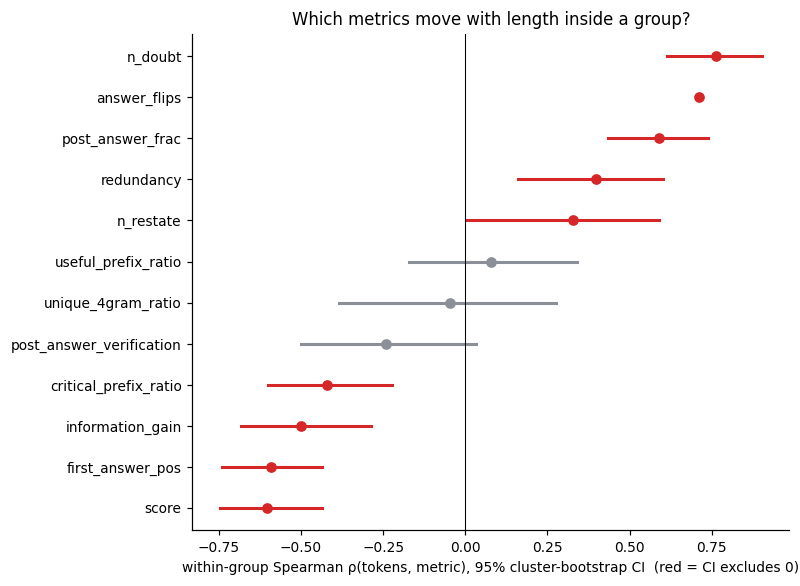

In [37]:
# Figure 1: within-group correlation of each metric with length (forest plot)
def fig_forest(sd):
    d = sd.sort_values("mean_within_rho").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(7, 0.38 * len(d) + 1.3))
    for i, r in d.iterrows():
        col = "#D62728" if (r.rho_ci_lo > 0 or r.rho_ci_hi < 0) else "#8A8F98"
        ax.plot([r.rho_ci_lo, r.rho_ci_hi], [i, i], color=col, lw=2); ax.plot(r.mean_within_rho, i, "o", color=col)
    ax.axvline(0, color="k", lw=0.7); ax.set_yticks(range(len(d))); ax.set_yticklabels(d.metric)
    ax.set_xlabel("within-group Spearman ρ(tokens, metric), 95% cluster-bootstrap CI  (red = CI excludes 0)"); ax.set_title("Which metrics move with length inside a group?")
    return fig
fig = fig_forest(stats_df); _save(fig, "fig1_length_vs_metrics_forest"); plt.show()

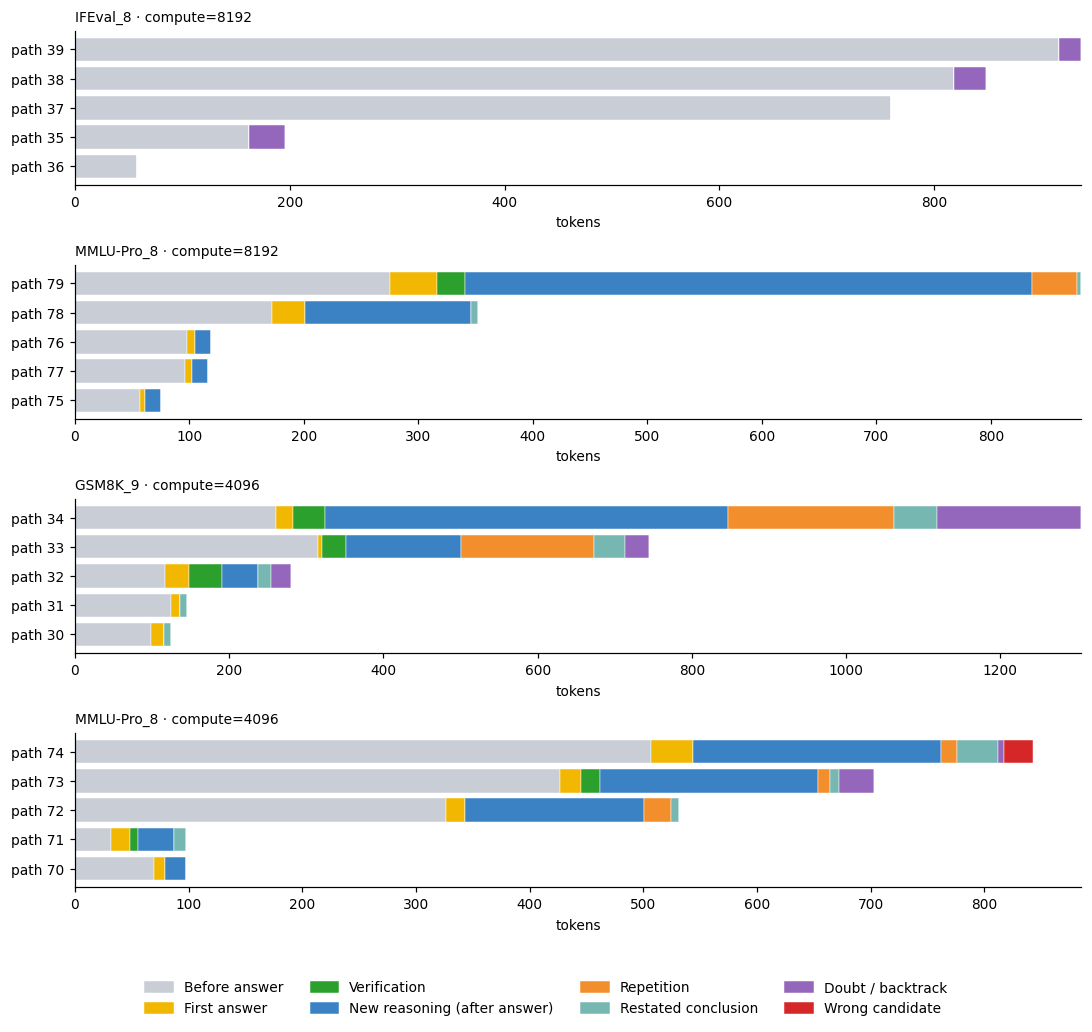

In [38]:
# Figure 2: what the tokens of each path consist of (longest-spread groups)
def fig_composition(groups):
    fig, axes = plt.subplots(len(groups), 1, figsize=(10, 2.0 * len(groups) + 1.2), squeeze=False)
    for ax, (q, l) in zip(axes[:, 0], groups):
        sub = path_tok[(path_tok.question_id == q) & (path_tok.compute_level == l)].sort_values("thinking_tokens")
        left = np.zeros(len(sub))
        for lab in LABELS:
            ax.barh(range(len(sub)), sub[lab].values, left=left, color=LABEL_STYLE[lab][0], edgecolor="white", linewidth=0.3); left += sub[lab].values
        ax.set_yticks(range(len(sub))); ax.set_yticklabels([f"path {int(i)}" for i in sub.index]); ax.set_title(f"{q} · compute={l}", loc="left", fontsize=9); ax.set_xlabel("tokens")
    fig.legend(handles=[Patch(color=LABEL_STYLE[k][0], label=LABEL_STYLE[k][1]) for k in LABELS], loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.06, 1, 1)); return fig
fig = fig_composition(VIZ); _save(fig, "fig2_token_composition"); plt.show()

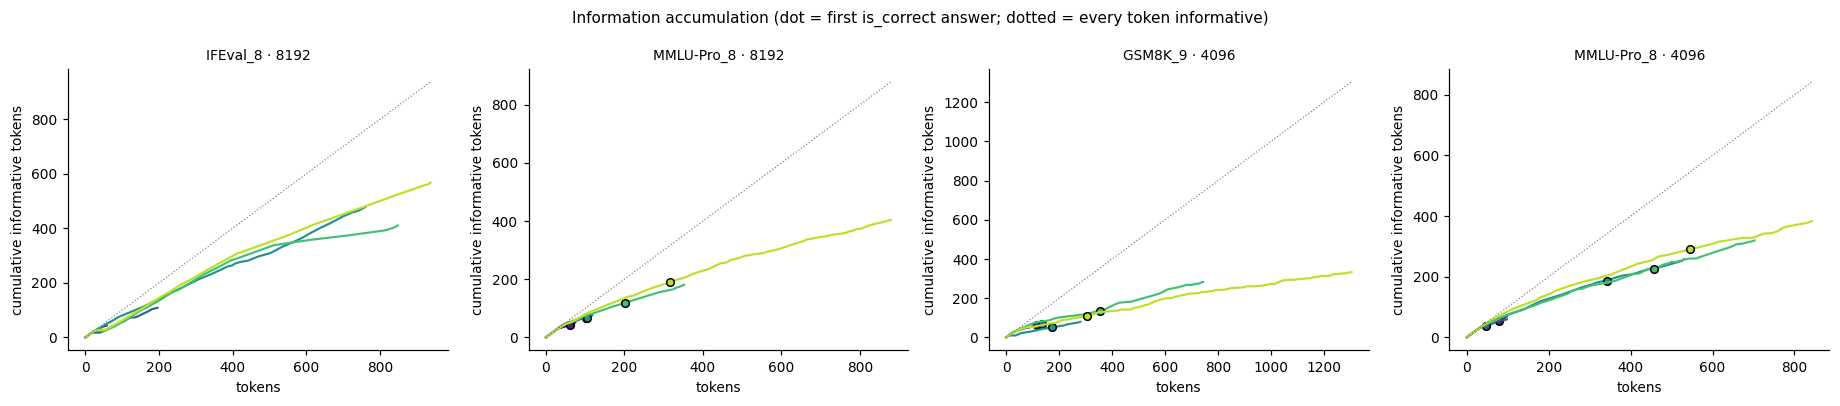

In [39]:
# Figure 3: cumulative informative tokens (novelty-weighted, doubt / wrong-candidate = 0) — a flattening curve means the extra tokens add little
def fig_cumulative_info(groups, x_mode):
    fig, axes = plt.subplots(1, len(groups), figsize=(4.2 * len(groups), 3.7), squeeze=False)
    for ax, (q, l) in zip(axes[0], groups):
        sub = path_tok[(path_tok.question_id == q) & (path_tok.compute_level == l)].sort_values("thinking_tokens")
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(sub))); top = 0
        for col, (rid, r) in zip(colors, sub.iterrows()):
            s = seg_df[seg_df.row_id == rid]; sc = r["thinking_tokens"] if x_mode == "relative" else 1.0
            x = np.r_[0, s["cum_tokens"].values] / sc; y = np.r_[0, s["cum_info"].values] / sc; top = max(top, x[-1])
            ax.plot(x, y, color=col, lw=1.4)
            fa = s[s.label == "first_answer"]
            if len(fa): ax.plot(fa["cum_tokens"].iloc[0] / sc, fa["cum_info"].iloc[0] / sc, "o", color=col, ms=5, mec="k")
        ax.plot([0, top], [0, top], ls=":", color="grey", lw=0.8)
        ax.set_title(f"{q} · {l}", fontsize=9); ax.set_xlabel("tokens" if x_mode == "tokens" else "fraction of trace"); ax.set_ylabel("cumulative informative tokens" if x_mode == "tokens" else "informative fraction")
    fig.suptitle("Information accumulation (dot = first is_correct answer; dotted = every token informative)", fontsize=10); fig.tight_layout(); return fig
fig = fig_cumulative_info(VIZ, CFG["viz_x_mode"]); _save(fig, "fig3_cumulative_information"); plt.show()

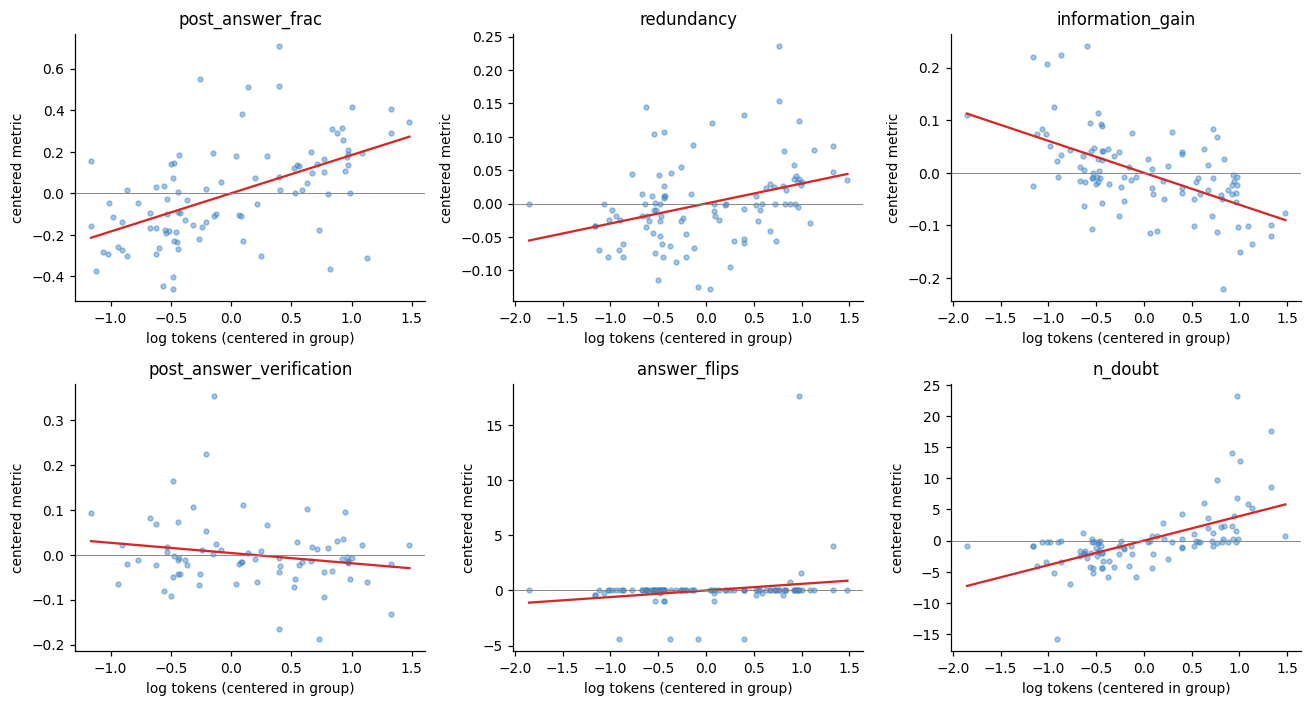

In [40]:
# Figure 4: within-group scatter (group-centered metric vs group-centered log tokens)
def fig_within_group_scatter(m, metrics):
    d = m[GK + ["thinking_tokens"] + metrics].copy(); d["lx"] = np.log(d["thinking_tokens"]); d["xc"] = d["lx"] - d.groupby(GK)["lx"].transform("mean")
    ncol = math.ceil(len(metrics) / 2); fig, axes = plt.subplots(2, ncol, figsize=(4 * ncol, 6.5), squeeze=False)
    for ax, met in zip(axes.ravel(), metrics):
        dd = d[GK + ["xc", met]].dropna(); yc = dd[met] - dd.groupby(GK)[met].transform("mean")
        ax.scatter(dd["xc"], yc, s=10, alpha=0.45, color="#3B82C4")
        if len(dd) > 3 and dd["xc"].std() > 0:
            b1, b0 = np.polyfit(dd["xc"], yc, 1); xs = np.linspace(dd["xc"].min(), dd["xc"].max(), 20); ax.plot(xs, b0 + b1 * xs, color="#D62728")
        ax.axhline(0, color="grey", lw=0.6); ax.set_title(met); ax.set_xlabel("log tokens (centered in group)"); ax.set_ylabel("centered metric")
    for ax in axes.ravel()[len(metrics):]: ax.axis("off")
    fig.tight_layout(); return fig
fig = fig_within_group_scatter(df_samples, ["post_answer_frac", "redundancy", "information_gain", "post_answer_verification", "answer_flips", "n_doubt"])
_save(fig, "fig4_within_group_scatter"); plt.show()

## 7. Save outputs and bottom line

In [42]:
outputs = {"path_metrics": df_samples, "segments": seg_df, "group_summary": group_df, "within_group_stats": stats_df, "sanity_checks": SAN,
           "extra_token_attribution_labels": attr_labels, "extra_token_attribution_buckets": attr_buckets}
for name, d in outputs.items(): d.to_csv(f"{RES_DIR}/{name}.csv", index=False)
print("saved to", RES_DIR, "->", sorted(os.listdir(RES_DIR)))

saved to results_reasoning_paths -> ['extra_token_attribution_buckets.csv', 'extra_token_attribution_labels.csv', 'figures', 'group_summary.csv', 'path_metrics.csv', 'sanity_checks.csv', 'segments.csv', 'within_group_stats.csv']


In [43]:
S = stats_df.set_index("metric")
b = attr_buckets.set_index("component")["mean_share_of_extra_tokens"]
out = [f"- **Data:** {len(group_df)} equal-correctness groups, {int(group_df.substantial_length_spread.sum())} with max/min length ≥ {MIN_LEN_RATIO}×.",
       "- **Where the extra tokens go** (longest vs shortest path in a group): " + "; ".join(f"{k} {v:.0%}" for k, v in b.items()) + "."]
for met, what in [("information_gain", "late-trace novelty (information gain)"), ("post_answer_verification", "share of post-answer text that is verification"), ("redundancy", "semantic redundancy"),
                  ("answer_flips", "answer flips"), ("n_doubt", "doubt / backtracking cues"), ("score", "combined efficiency score")]:
    r = S.loc[met]; out.append(f"- **{what}:** ρ = {r.mean_within_rho:+.2f} [{r.rho_ci_lo:+.2f}, {r.rho_ci_hi:+.2f}] → {direction(r)}.")
ig = S.loc["information_gain"]
verdict = ("Longer paths carry *more* late-trace novelty: extra tokens look informative under these proxies." if ig.rho_ci_lo > 0 else
           "Longer paths carry *less* late-trace novelty: extra tokens look like padding under these proxies." if ig.rho_ci_hi < 0 else
           "No reliable relation between length and late-trace novelty: the proxies cannot tell informative from padded extra tokens.")
out.append(f"\n**Reading:** {verdict}")
out.append("\n*Associations between length and text-derived proxies inside question × compute groups — not causal. A truncate-and-regenerate experiment is needed to test what can safely be cut.*")
display(Markdown("\n".join(out)))

- **Data:** 20 equal-correctness groups, 20 with max/min length ≥ 1.5×.
- **Where the extra tokens go** (longest vs shortest path in a group): needed to reach the answer 33%; post-answer verification / new reasoning 39%; repetition / restatement / doubt / wrong candidates 28%.
- **late-trace novelty (information gain):** ρ = -0.50 [-0.68, -0.29] → falls with length.
- **share of post-answer text that is verification:** ρ = -0.24 [-0.50, +0.03] → no reliable change with length.
- **semantic redundancy:** ρ = +0.40 [+0.16, +0.60] → rises with length.
- **answer flips:** ρ = +0.71 [+0.71, +0.72] → rises with length.
- **doubt / backtracking cues:** ρ = +0.76 [+0.61, +0.90] → rises with length.
- **combined efficiency score:** ρ = -0.60 [-0.75, -0.44] → falls with length.

**Reading:** Longer paths carry *less* late-trace novelty: extra tokens look like padding under these proxies.

*Associations between length and text-derived proxies inside question × compute groups — not causal. A truncate-and-regenerate experiment is needed to test what can safely be cut.*